# Australian CPI Forecasting EDA

This notebook performs a screening-stage EDA pass over the curated quarterly macro table for SARIMA/SARIMAX/LSTM modelling. Statistical screens are treated as indicative only because the sample is small and several predictors have early missingness. Forecast-origin availability is represented as an explicit assumption set, not as a fact derived from the curated schema.

In [12]:
from pathlib import Path
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, kpss

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.platform_validation import validate_curated_with_pandera
from src.validation import validate_curated_dataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = ROOT / 'data' / 'curated' / 'quarterly_macro_features.csv'
AVAILABILITY_PATH = ROOT / 'data' / 'metadata' / 'series_availability.csv'
TARGET = 'cpi_yoy'
MAX_LAG = 4
SIGNAL_P_THRESHOLD = 0.10
SIGNAL_CORR_THRESHOLD = 0.20
MATERIAL_MISSING_THRESHOLD = 0.20
VIF_THRESHOLD = 10.0

## 1. Data Integrity Checks

In [13]:
df = pd.read_csv(DATA_PATH)
df['quarter_period'] = pd.PeriodIndex(df['quarter'], freq='Q')
df['quarter_start'] = df['quarter_period'].dt.to_timestamp(how='start')
df = df.sort_values('quarter_period').reset_index(drop=True)
df_model = df.drop(columns=['quarter_period', 'quarter_start'])

schema = pd.DataFrame({'column': df_model.columns, 'dtype': df_model.dtypes.astype(str).values})
display(schema)
display(df_model.head())

validation_records = [record.as_dict() for record in validate_curated_dataset(df_model)]
validation_records.append(validate_curated_with_pandera(df_model).as_dict())
validation_summary = pd.DataFrame(validation_records)
display(validation_summary.head(16))

quarters = df['quarter_period']
expected_quarters = pd.period_range(quarters.min(), quarters.max(), freq='Q')
integrity_summary = pd.DataFrame([
    {'check': 'row_count', 'value': len(df)},
    {'check': 'column_count', 'value': len(df_model.columns)},
    {'check': 'start_quarter', 'value': str(quarters.min())},
    {'check': 'end_quarter', 'value': str(quarters.max())},
    {'check': 'duplicate_quarters', 'value': int(df['quarter'].duplicated().sum())},
    {'check': 'missing_quarters', 'value': int(len(expected_quarters.difference(quarters)))},
    {'check': 'is_sorted', 'value': bool(quarters.is_monotonic_increasing)},
])
display(integrity_summary)

,column,dtype
0,quarter,str
1,cpi_index,float64
2,cpi_qoq,float64
3,cpi_yoy,float64
4,unemployment_rate,float64
5,cash_rate,float64
6,wage_price_index,float64
7,wpi_growth,float64
8,producer_price_index,float64
9,ppi_growth,float64


,quarter,cpi_index,cpi_qoq,cpi_yoy,unemployment_rate,cash_rate,wage_price_index,wpi_growth,producer_price_index,ppi_growth,commodity_price_index,commodity_growth,wti_price,wti_growth,brent_price,brent_growth,aud_usd,aud_usd_change,household_spending,household_spending_growth,inflation_expectations_business,cpi_yoy_lag1,cpi_yoy_lag4,cash_rate_lag1,cash_rate_lag2,cash_rate_lag4,unemployment_rate_lag1,unemployment_rate_lag2,unemployment_rate_lag4,wpi_growth_lag1,wpi_growth_lag2,ppi_growth_lag1,ppi_growth_lag2,commodity_growth_lag1,wti_growth_lag1,brent_growth_lag1,aud_usd_change_lag1,inflation_expectations_business_lag1
0,1995Q1,44.34,NaN,NaN,8.765343,7.5,NaN,NaN,NaN,NaN,29.996283,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995Q2,44.92,1.308074,NaN,8.364921,7.5,NaN,NaN,NaN,NaN,31.011010,3.382842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.39,NaN,NaN,7.5,NaN,NaN,8.765343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.02
2,1995Q3,45.46,1.202137,NaN,8.370487,7.5,NaN,NaN,NaN,NaN,30.733831,-0.893806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.28,NaN,NaN,7.5,7.5,NaN,8.364921,8.765343,NaN,NaN,NaN,NaN,NaN,3.382842,NaN,NaN,NaN,4.39
3,1995Q4,45.81,0.769908,NaN,8.390849,7.5,NaN,NaN,NaN,NaN,30.162208,-1.859915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.58,NaN,NaN,7.5,7.5,NaN,8.370487,8.364921,NaN,NaN,NaN,NaN,NaN,-0.893806,NaN,NaN,NaN,3.28
4,1996Q1,46.00,0.414757,3.743798,8.400038,7.5,NaN,NaN,NaN,NaN,29.976517,-0.615640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.26,NaN,NaN,7.5,7.5,7.5,8.390849,8.370487,8.765343,NaN,NaN,NaN,NaN,-1.859915,NaN,NaN,NaN,2.58


,dataset,status,rows,columns,start_date,end_date,missing_values,duplicate_dates,notes
0,curated_quarterly_macro_features,PASS,124,38,1995Q1,2025Q4,690,0,ok
1,curated_column:cpi_index,PASS,124,1,1995Q1,2025Q4,0,0,ok
2,curated_column:cpi_qoq,PASS,123,1,1995Q1,2025Q4,1,0,ok
3,curated_column:cpi_yoy,PASS,120,1,1995Q1,2025Q4,4,0,ok
4,curated_column:unemployment_rate,PASS,124,1,1995Q1,2025Q4,0,0,ok
5,curated_column:cash_rate,PASS,124,1,1995Q1,2025Q4,0,0,ok
6,curated_column:wage_price_index,PASS,114,1,1995Q1,2025Q4,10,0,ok
7,curated_column:wpi_growth,PASS,113,1,1995Q1,2025Q4,11,0,ok
8,curated_column:producer_price_index,PASS,110,1,1995Q1,2025Q4,14,0,ok
9,curated_column:ppi_growth,PASS,109,1,1995Q1,2025Q4,15,0,ok


,check,value
0,row_count,124
1,column_count,38
2,start_quarter,1995Q1
3,end_quarter,2025Q4
4,duplicate_quarters,0
5,missing_quarters,0
6,is_sorted,True


## 2. Missing Values And Coverage

In [14]:
def first_last_non_null_date(frame: pd.DataFrame, column: str) -> tuple[str | None, str | None]:
    mask = frame[column].notna()
    if not mask.any():
        return None, None
    return str(frame.loc[mask, 'quarter_period'].iloc[0]), str(frame.loc[mask, 'quarter_period'].iloc[-1])


coverage_rows = []
for column in df_model.columns:
    if column == 'quarter':
        continue
    first_non_null, last_non_null = first_last_non_null_date(df, column)
    missing_count = int(df[column].isna().sum())
    coverage_rows.append({
        'variable': column,
        'non_null_rows': int(df[column].notna().sum()),
        'missing_count': missing_count,
        'missing_pct': missing_count / len(df),
        'first_non_null': first_non_null,
        'last_non_null': last_non_null,
        'material_early_missingness': bool(missing_count / len(df) >= MATERIAL_MISSING_THRESHOLD or first_non_null not in {None, str(df['quarter_period'].min())}),
    })

coverage = pd.DataFrame(coverage_rows).sort_values(['missing_pct', 'variable'], ascending=[False, True])
display(coverage)
display(coverage.loc[coverage['material_early_missingness'], ['variable', 'missing_pct', 'first_non_null', 'last_non_null']])

,variable,non_null_rows,missing_count,missing_pct,first_non_null,last_non_null,material_early_missingness
18,household_spending_growth,53,71,0.572581,2012Q4,2025Q4,True
17,household_spending,54,70,0.564516,2012Q3,2025Q4,True
35,aud_usd_change_lag1,62,62,0.500000,2010Q3,2025Q4,True
16,aud_usd_change,63,61,0.491935,2010Q2,2025Q4,True
15,aud_usd,64,60,0.483871,2010Q1,2025Q4,True
34,brent_growth_lag1,72,52,0.419355,2008Q1,2025Q4,True
14,brent_growth,73,51,0.411290,2007Q4,2025Q4,True
13,brent_price,74,50,0.403226,2007Q3,2025Q4,True
33,wti_growth_lag1,100,24,0.193548,2001Q1,2025Q4,True
12,wti_growth,101,23,0.185484,2000Q4,2025Q4,True


,variable,missing_pct,first_non_null,last_non_null
18,household_spending_growth,0.572581,2012Q4,2025Q4
17,household_spending,0.564516,2012Q3,2025Q4
35,aud_usd_change_lag1,0.500000,2010Q3,2025Q4
16,aud_usd_change,0.491935,2010Q2,2025Q4
15,aud_usd,0.483871,2010Q1,2025Q4
34,brent_growth_lag1,0.419355,2008Q1,2025Q4
14,brent_growth,0.411290,2007Q4,2025Q4
13,brent_price,0.403226,2007Q3,2025Q4
33,wti_growth_lag1,0.193548,2001Q1,2025Q4
12,wti_growth,0.185484,2000Q4,2025Q4


## 3. CPI Target Inspection

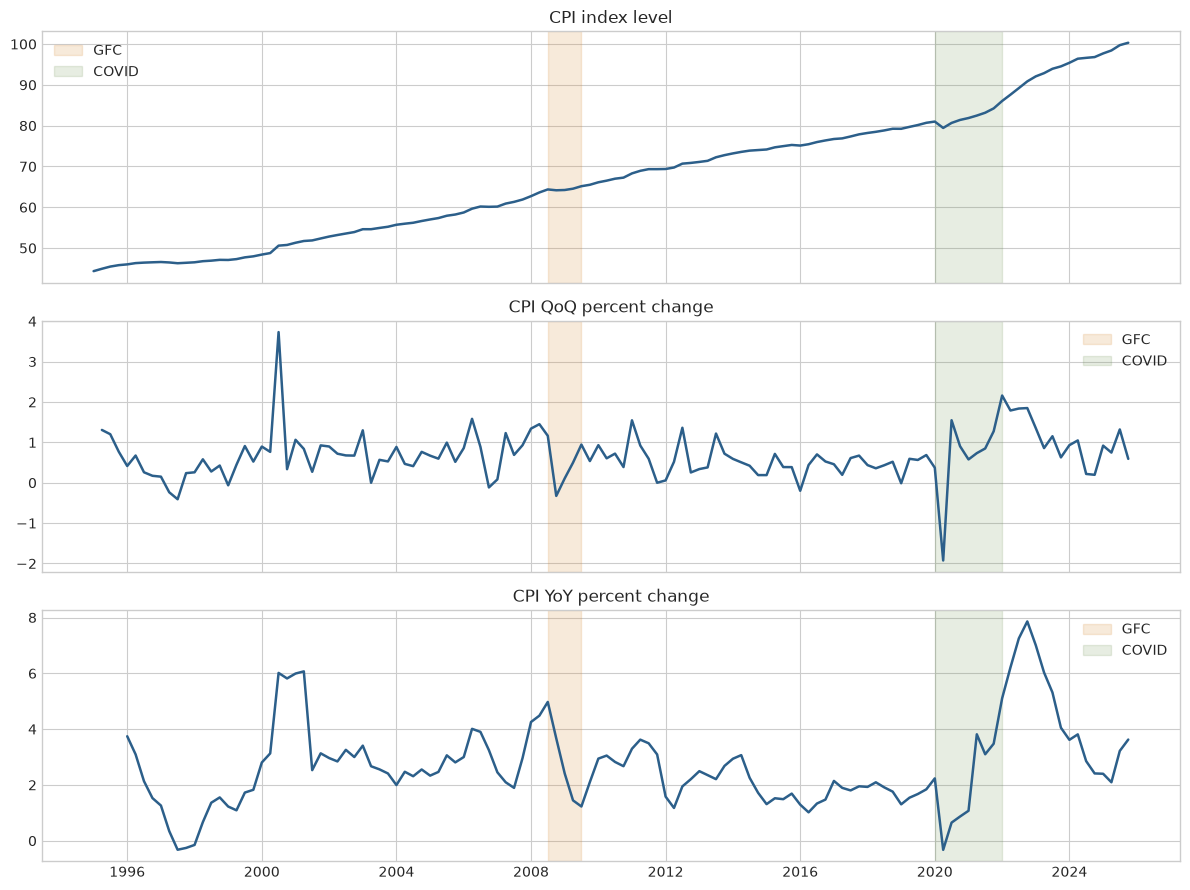

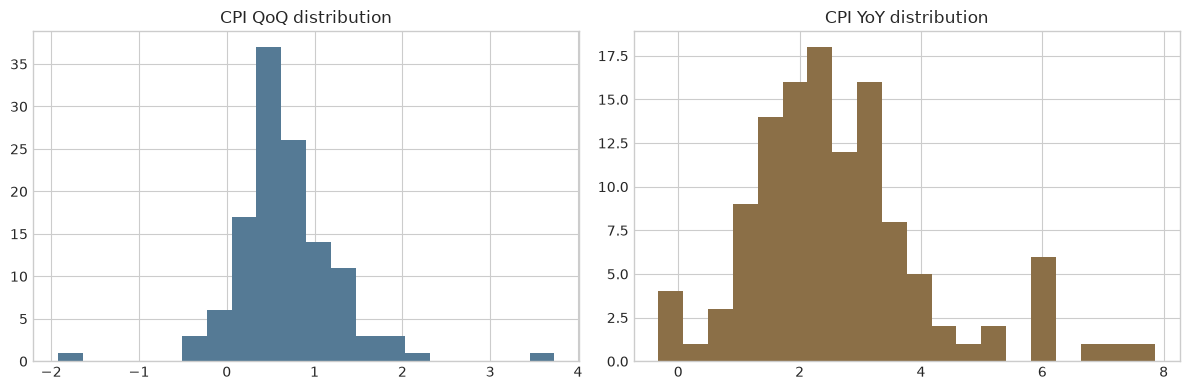

,quarter,metric,value,z_score
0,2000Q3,cpi_qoq,3.731802,5.21
1,2020Q2,cpi_qoq,-1.925926,-4.41
2,2022Q1,cpi_qoq,2.160750,2.54
3,2022Q3,cpi_yoy,7.250210,3.02
4,2022Q4,cpi_yoy,7.859433,3.42
5,2023Q1,cpi_yoy,7.007554,2.86


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, column, title in zip(axes, ['cpi_index', 'cpi_qoq', 'cpi_yoy'], ['CPI index level', 'CPI QoQ percent change', 'CPI YoY percent change']):
    ax.plot(df['quarter_start'], df[column], color='#2c5f8a', linewidth=1.8)
    ax.set_title(title)
    ax.axvspan(pd.Period('2008Q3', freq='Q').to_timestamp(), pd.Period('2009Q3', freq='Q').to_timestamp(), color='#d88c36', alpha=0.18, label='GFC')
    ax.axvspan(pd.Period('2020Q1', freq='Q').to_timestamp(), pd.Period('2022Q1', freq='Q').to_timestamp(), color='#6a8f4e', alpha=0.16, label='COVID')
    ax.legend(loc='best')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['cpi_qoq'].dropna().hist(ax=axes[0], bins=20, color='#557a95')
axes[0].set_title('CPI QoQ distribution')
df['cpi_yoy'].dropna().hist(ax=axes[1], bins=20, color='#8b6f47')
axes[1].set_title('CPI YoY distribution')
fig.tight_layout()
plt.show()

outlier_rows = []
for column in ['cpi_qoq', 'cpi_yoy']:
    series = df[column]
    z_score = (series - series.mean()) / series.std(ddof=0)
    flagged = df.loc[z_score.abs() >= 2.5, ['quarter', column]].copy()
    flagged['metric'] = column
    flagged['z_score'] = z_score.loc[flagged.index].round(2)
    outlier_rows.append(flagged[['quarter', 'metric', column, 'z_score']].rename(columns={column: 'value'}))
outliers = pd.concat(outlier_rows, ignore_index=True) if outlier_rows else pd.DataFrame()
display(outliers)

## 4. External Variable Inspection

These plots z-score the raw curated predictor columns against CPI YoY for visual inspection only. Use the stationarity-aware CCF and Granger tables below for correlation evidence.

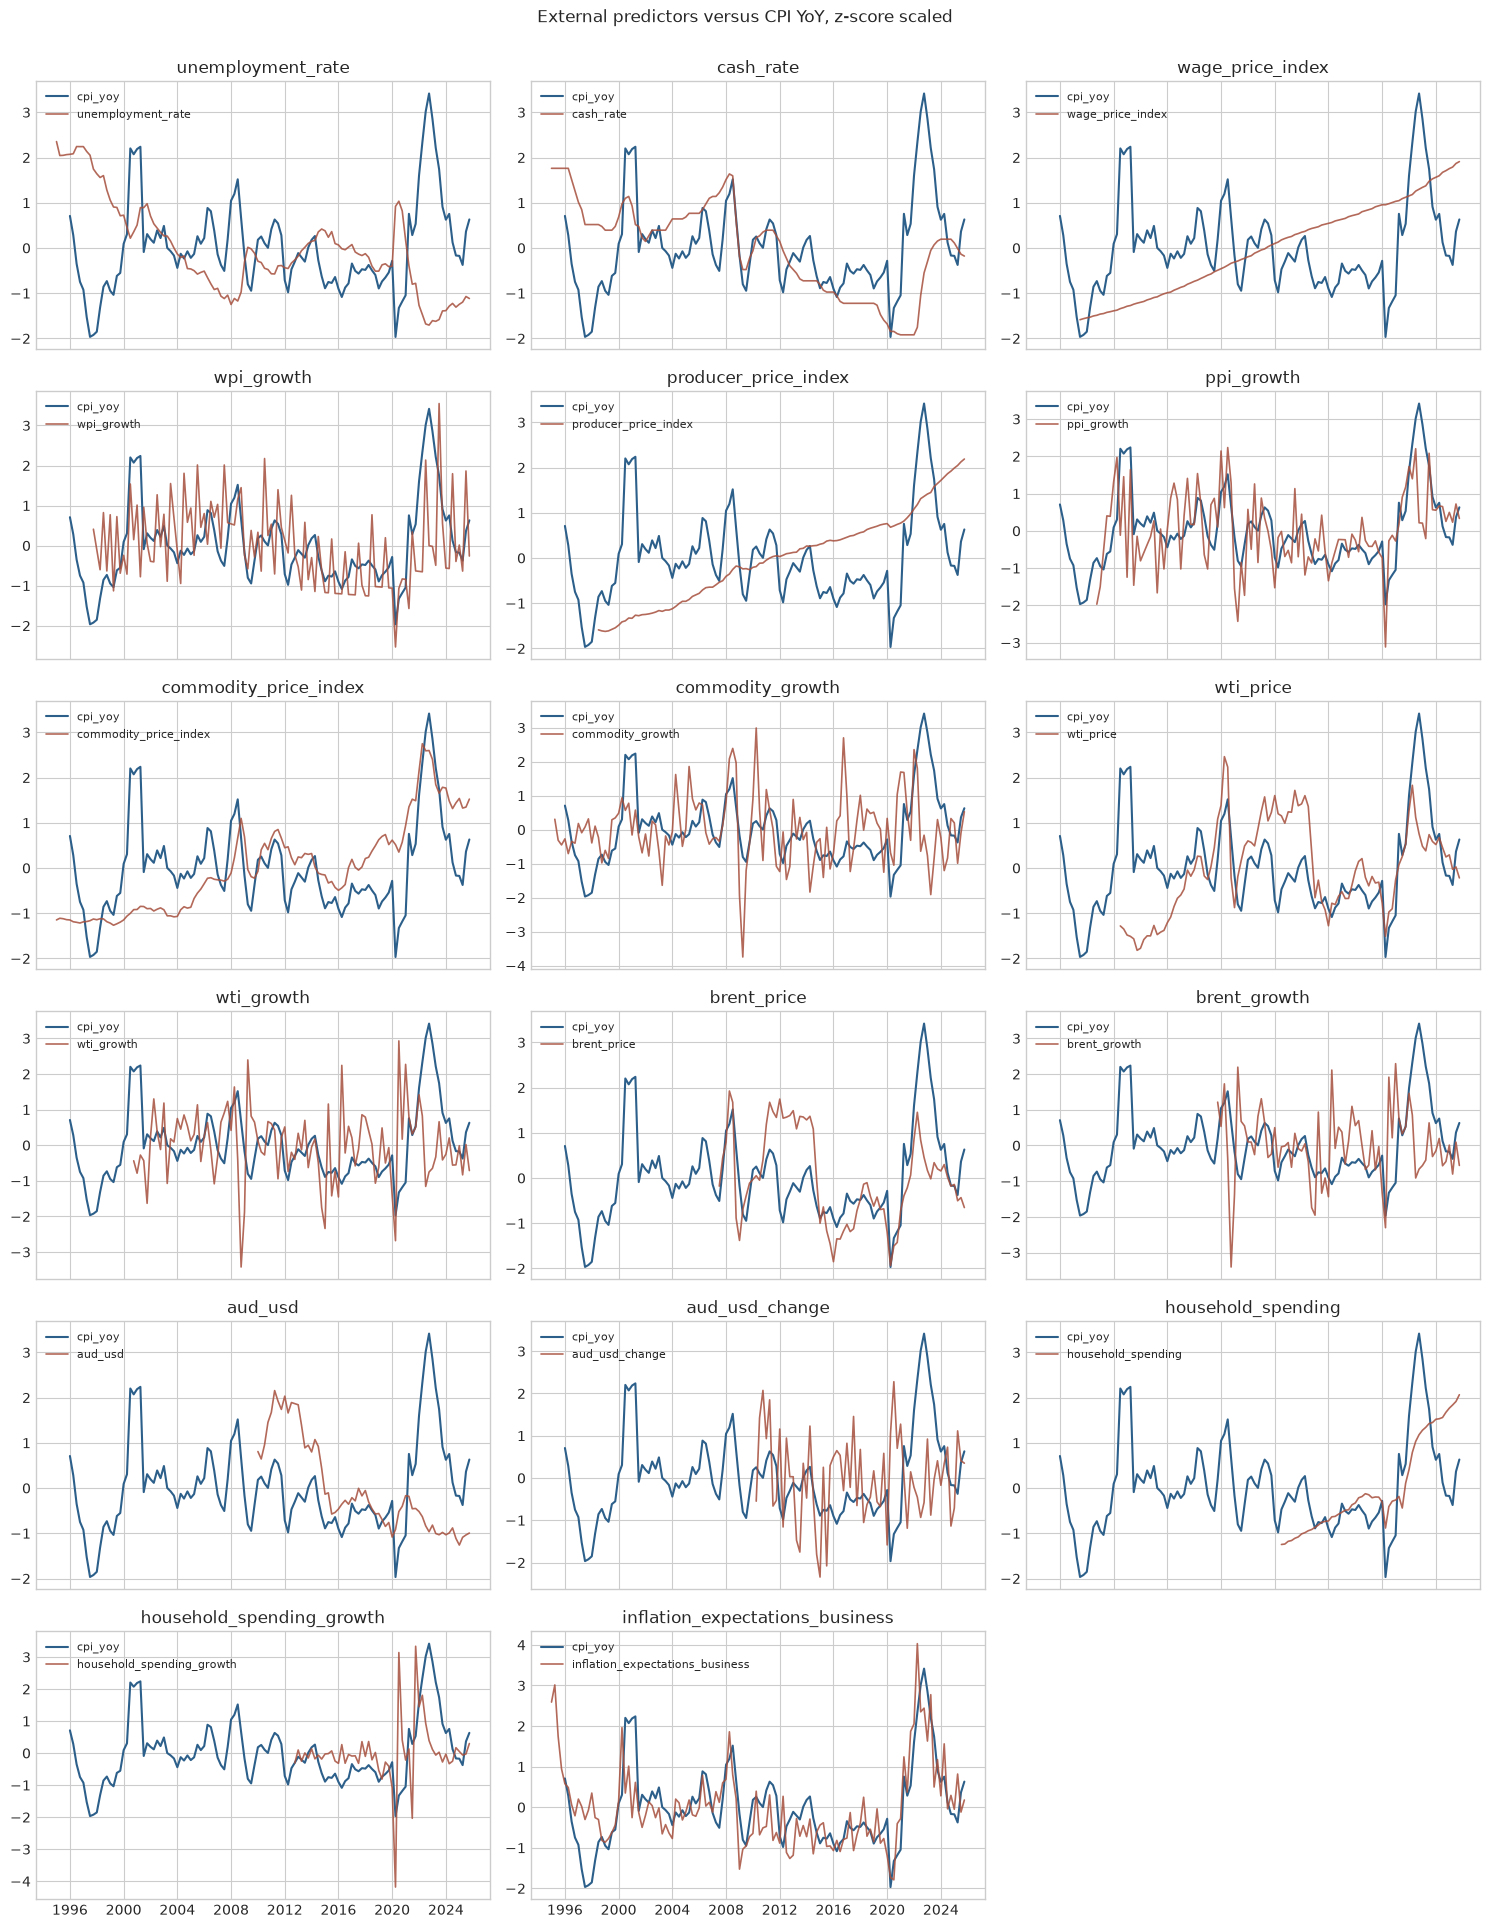

,external_base_variable
0,unemployment_rate
1,cash_rate
2,wage_price_index
3,wpi_growth
4,producer_price_index
5,ppi_growth
6,commodity_price_index
7,commodity_growth
8,wti_price
9,wti_growth


,lagged_feature_from_src_features
0,cash_rate_lag1
1,cash_rate_lag2
2,cash_rate_lag4
3,unemployment_rate_lag1
4,unemployment_rate_lag2
5,unemployment_rate_lag4
6,wpi_growth_lag1
7,wpi_growth_lag2
8,ppi_growth_lag1
9,ppi_growth_lag2


In [16]:
EXTERNAL_BASE_COLS = [
    column for column in df_model.columns
    if column not in {'quarter', 'cpi_index', 'cpi_qoq', 'cpi_yoy'} and '_lag' not in column
]
EXTERNAL_LAGGED_FEATURES = [column for column in df_model.columns if '_lag' in column and not column.startswith('cpi_')]

def zscore(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    std = numeric.std(ddof=0)
    if pd.isna(std) or std == 0:
        return numeric * np.nan
    return (numeric - numeric.mean()) / std


n_cols = 3
n_rows = int(np.ceil(len(EXTERNAL_BASE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.2 * n_rows)), sharex=True)
axes = np.array(axes).reshape(-1)
for ax, column in zip(axes, EXTERNAL_BASE_COLS):
    ax.plot(df['quarter_start'], zscore(df[TARGET]), label=TARGET, color='#2c5f8a', linewidth=1.5)
    ax.plot(df['quarter_start'], zscore(df[column]), label=column, color='#a64f3c', linewidth=1.2, alpha=0.85)
    ax.set_title(column)
    ax.legend(fontsize=8)
for ax in axes[len(EXTERNAL_BASE_COLS):]:
    ax.axis('off')
fig.suptitle('External predictors versus CPI YoY, z-score scaled', y=1.002)
fig.tight_layout()
plt.show()

display(pd.DataFrame({'external_base_variable': EXTERNAL_BASE_COLS}))
display(pd.DataFrame({'lagged_feature_from_src_features': EXTERNAL_LAGGED_FEATURES}))

## 5. Stationarity Tests

In [17]:
eda_df = df.set_index('quarter_period')
STATIONARITY_COLS = ['cpi_index', 'cpi_qoq', 'cpi_yoy'] + EXTERNAL_BASE_COLS

def clean_series(column: str) -> pd.Series:
    return pd.to_numeric(eda_df[column], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()


def safe_adf(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 12 or series.nunique() < 3:
        return np.nan
    try:
        return float(adfuller(series, autolag='AIC')[1])
    except Exception:
        return np.nan


def safe_kpss(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 12 or series.nunique() < 3:
        return np.nan
    try:
        return float(kpss(series, regression='c', nlags='auto')[1])
    except Exception:
        return np.nan


def is_growth_or_change_column(column: str) -> bool:
    return column in {'cpi_qoq', 'cpi_yoy'} or column.endswith('_growth') or column.endswith('_change')


def should_use_log_diff(column: str, series: pd.Series) -> bool:
    return not is_growth_or_change_column(column) and len(series) > 0 and float((series > 0).mean()) >= 0.80


def stationarity_variants(column: str, series: pd.Series) -> dict[str, pd.Series]:
    variants = {
        'level': series,
        'diff1': series.diff(),
        'diff2': series.diff().diff(),
    }
    variants['log_diff1'] = np.log(series.where(series > 0)).diff() if should_use_log_diff(column, series) else pd.Series(dtype='float64')
    return variants


def integration_order_from_tests(row: pd.Series) -> str:
    def stationary(prefix: str) -> bool:
        adf_ok = pd.notna(row[f'{prefix}_adf_p']) and row[f'{prefix}_adf_p'] < 0.05
        kpss_ok = pd.notna(row[f'{prefix}_kpss_p']) and row[f'{prefix}_kpss_p'] > 0.05
        return bool(adf_ok and kpss_ok)
    if stationary('level'):
        return 'I(0)'
    if stationary('diff1') or stationary('log_diff1'):
        return 'I(1)'
    if stationary('diff2'):
        return 'I(2)'
    return 'unclear'


stationarity_rows = []
for column in STATIONARITY_COLS:
    series = clean_series(column)
    row = {'variable': column, 'n_obs': int(len(series))}
    for variant_name, variant_series in stationarity_variants(column, series).items():
        row[f'{variant_name}_adf_p'] = safe_adf(variant_series)
        row[f'{variant_name}_kpss_p'] = safe_kpss(variant_series)
    stationarity_rows.append(row)

stationarity = pd.DataFrame(stationarity_rows)
stationarity['integration_order'] = stationarity.apply(integration_order_from_tests, axis=1)
display(stationarity.round(4))

,variable,n_obs,level_adf_p,level_kpss_p,diff1_adf_p,diff1_kpss_p,diff2_adf_p,diff2_kpss_p,log_diff1_adf_p,log_diff1_kpss_p,integration_order
0,cpi_index,124,1.0000,0.010,0.0000,0.0183,0.0000,0.1000,0.0000,0.1000,I(1)
1,cpi_qoq,123,0.0000,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0)
2,cpi_yoy,120,0.0224,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0)
3,unemployment_rate,124,0.2714,0.010,0.0000,0.1000,0.0000,0.1000,0.0000,0.1000,I(1)
4,cash_rate,124,0.1866,0.010,0.0000,0.1000,0.0000,0.1000,0.0000,0.1000,I(1)
5,wage_price_index,114,0.9948,0.010,0.3847,0.0187,0.0031,0.1000,0.3866,0.0209,I(2)
6,wpi_growth,113,0.3861,0.021,0.0008,0.1000,0.0000,0.1000,NaN,NaN,I(1)
7,producer_price_index,110,0.9954,0.010,0.0004,0.0707,0.0000,0.1000,0.0000,0.1000,I(1)
8,ppi_growth,109,0.0000,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0)
9,commodity_price_index,124,0.7898,0.010,0.0000,0.1000,0.0000,0.1000,0.0000,0.1000,I(1)


## 6. Lead-Lag Correlation Analysis

,variable,lag_quarters,correlation,n_obs,abs_correlation
149,inflation_expectations_business,1,0.7317,120,0.7317
14,cash_rate,1,0.5616,120,0.5616
51,ppi_growth,2,0.5524,107,0.5524
42,producer_price_index,2,0.5517,107,0.5517
142,household_spending_growth,3,0.4893,50,0.4893
133,household_spending,3,0.4762,50,0.4762
95,brent_price,1,0.4711,73,0.4711
106,brent_growth,3,0.3621,70,0.3621
88,wti_growth,3,0.3438,98,0.3438
79,wti_price,3,0.3433,98,0.3433


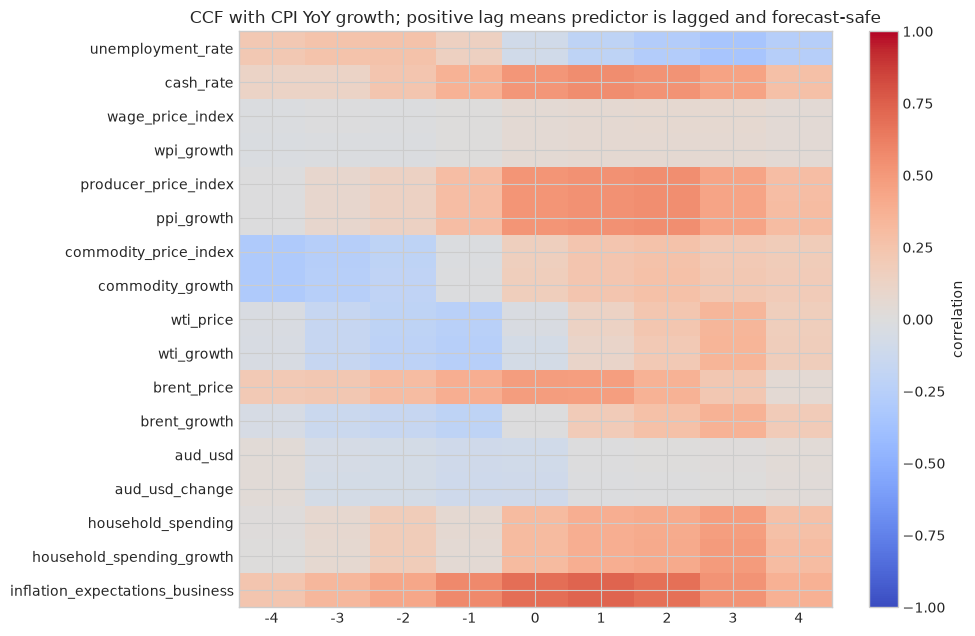

In [18]:
integration_lookup = dict(zip(stationarity['variable'], stationarity['integration_order']))

def stationary_series(column: str) -> pd.Series:
    series = clean_series(column)
    order = integration_lookup.get(column, 'unclear')
    if order == 'I(0)':
        result = series
    elif order == 'I(2)':
        result = series.diff().diff()
    else:
        log_diff = np.log(series.where(series > 0)).diff() if should_use_log_diff(column, series) else pd.Series(dtype='float64')
        result = log_diff if log_diff.notna().sum() >= 12 else series.diff()
    return result.replace([np.inf, -np.inf], np.nan).dropna()


target_stationary = stationary_series(TARGET).rename(TARGET)
ccf_rows = []
for column in EXTERNAL_BASE_COLS:
    x = stationary_series(column).rename(column)
    for lag in range(-MAX_LAG, MAX_LAG + 1):
        aligned = pd.concat([target_stationary, x.shift(lag)], axis=1).dropna()
        corr = aligned[TARGET].corr(aligned[column]) if len(aligned) >= 12 else np.nan
        ccf_rows.append({'variable': column, 'lag_quarters': lag, 'correlation': corr, 'n_obs': len(aligned)})

ccf = pd.DataFrame(ccf_rows)
positive_lag_ccf = ccf.loc[ccf['lag_quarters'] > 0].dropna(subset=['correlation']).copy()
best_predictive_ccf = (
    positive_lag_ccf.assign(abs_correlation=lambda frame: frame['correlation'].abs())
    .sort_values(['variable', 'abs_correlation'], ascending=[True, False])
    .groupby('variable', as_index=False)
    .head(1)
    .sort_values('abs_correlation', ascending=False)
)
display(best_predictive_ccf.round(4))

heatmap_data = ccf.pivot(index='variable', columns='lag_quarters', values='correlation').loc[EXTERNAL_BASE_COLS]
fig, ax = plt.subplots(figsize=(10, max(4, 0.38 * len(EXTERNAL_BASE_COLS))))
image = ax.imshow(heatmap_data, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('CCF with CPI YoY growth; positive lag means predictor is lagged and forecast-safe')
fig.colorbar(image, ax=ax, label='correlation')
fig.tight_layout()
plt.show()

## 7. Granger Causality Screening

In [19]:
best_lag_lookup = dict(zip(best_predictive_ccf['variable'], best_predictive_ccf['lag_quarters']))

def granger_screen(variable: str) -> dict[str, object]:
    x = stationary_series(variable).rename(variable)
    data = pd.concat([target_stationary.rename(TARGET), x], axis=1).dropna()
    max_lag = min(MAX_LAG, max(1, len(data) // 10))
    selected_lag = int(best_lag_lookup.get(variable, 1))
    selected_lag = min(max(selected_lag, 1), max_lag)
    if len(data) < 24 or data[variable].nunique() < 3:
        return {'variable': variable, 'selected_lag': selected_lag, 'granger_p_value': np.nan, 'tested_lags': '', 'n_obs': len(data), 'note': 'insufficient stationary observations'}
    try:
        result = grangercausalitytests(data[[TARGET, variable]], maxlag=max_lag, verbose=False)
        p_values = {lag: float(result[lag][0]['ssr_ftest'][1]) for lag in range(1, max_lag + 1)}
        return {
            'variable': variable,
            'selected_lag': selected_lag,
            'granger_p_value': p_values.get(selected_lag, np.nan),
            'min_granger_p_value': min(p_values.values()) if p_values else np.nan,
            'tested_lags': ', '.join(f'{lag}:{p_value:.3f}' for lag, p_value in p_values.items()),
            'n_obs': len(data),
            'note': 'screening signal only',
        }
    except Exception as exc:
        return {'variable': variable, 'selected_lag': selected_lag, 'granger_p_value': np.nan, 'min_granger_p_value': np.nan, 'tested_lags': '', 'n_obs': len(data), 'note': f'granger failed: {type(exc).__name__}'}


granger = pd.DataFrame([granger_screen(column) for column in EXTERNAL_BASE_COLS])
display(granger.sort_values('granger_p_value', na_position='last').round(4))

,variable,selected_lag,granger_p_value,min_granger_p_value,tested_lags,n_obs,note
16,inflation_expectations_business,1,0.0001,0.0000,"1:0.000, 2:0.000, 3:0.000, 4:0.000",120,screening signal only
9,wti_growth,3,0.0001,0.0000,"1:0.002, 2:0.006, 3:0.000, 4:0.000",101,screening signal only
8,wti_price,3,0.0006,0.0001,"1:0.003, 2:0.008, 3:0.001, 4:0.000",101,screening signal only
15,household_spending_growth,3,0.0023,0.0023,"1:0.058, 2:0.068, 3:0.002, 4:0.008",53,screening signal only
1,cash_rate,1,0.0030,0.0030,"1:0.003, 2:0.038, 3:0.097, 4:0.028",120,screening signal only
11,brent_growth,3,0.0037,0.0003,"1:0.000, 2:0.013, 3:0.004, 4:0.001",73,screening signal only
14,household_spending,3,0.0057,0.0057,"1:0.074, 2:0.101, 3:0.006, 4:0.012",53,screening signal only
5,ppi_growth,2,0.0098,0.0098,"1:0.033, 2:0.010, 3:0.095, 4:0.148",109,screening signal only
4,producer_price_index,2,0.0100,0.0100,"1:0.033, 2:0.010, 3:0.098, 4:0.150",109,screening signal only
0,unemployment_rate,3,0.1462,0.0061,"1:0.006, 2:0.072, 3:0.146, 4:0.201",120,screening signal only


## 8. Multicollinearity And VIF

,candidate_sarimax_feature
0,brent_growth_lag1
1,cash_rate_lag1
2,commodity_growth_lag1
3,inflation_expectations_business_lag1
4,ppi_growth_lag2
5,unemployment_rate_lag4
6,wti_growth_lag1


,complete_rows_for_corr_vif,start_quarter,end_quarter
0,72,2008Q1,2025Q4


,brent_growth_lag1,cash_rate_lag1,commodity_growth_lag1,inflation_expectations_business_lag1,ppi_growth_lag2,unemployment_rate_lag4,wti_growth_lag1
brent_growth_lag1,1.000,-0.043,0.100,0.109,-0.195,0.121,0.975
cash_rate_lag1,-0.043,1.000,0.014,0.150,0.305,-0.580,-0.074
commodity_growth_lag1,0.100,0.014,1.000,0.251,0.231,0.211,0.059
inflation_expectations_business_lag1,0.109,0.150,0.251,1.000,0.623,-0.387,0.086
ppi_growth_lag2,-0.195,0.305,0.231,0.623,1.000,-0.372,-0.262
unemployment_rate_lag4,0.121,-0.580,0.211,-0.387,-0.372,1.000,0.115
wti_growth_lag1,0.975,-0.074,0.059,0.086,-0.262,0.115,1.000


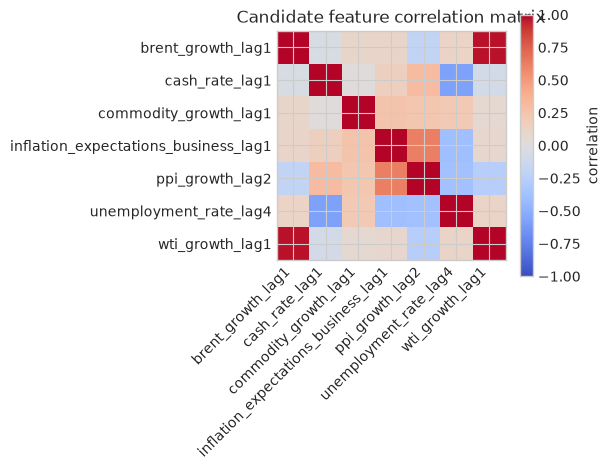

,candidate_feature,vif
6,wti_growth_lag1,24.308
0,brent_growth_lag1,23.162
3,inflation_expectations_business_lag1,6.597
4,ppi_growth_lag2,4.545
5,unemployment_rate_lag4,3.857
1,cash_rate_lag1,3.260
2,commodity_growth_lag1,1.130


In [20]:
def lag_base_name(feature: str) -> str:
    return re.sub(r'_lag\d+$', '', feature)


def feature_lag(feature: str) -> int | None:
    match = re.search(r'_lag(\d+)$', feature)
    return int(match.group(1)) if match else None


availability_assumptions = pd.read_csv(AVAILABILITY_PATH)
availability_assumptions['assumed_min_safe_lag_quarters'] = availability_assumptions['assumed_min_safe_lag_quarters'].astype(int)
missing_availability_metadata = sorted(set(EXTERNAL_BASE_COLS) - set(availability_assumptions['variable']))
if missing_availability_metadata:
    raise ValueError(f'Missing availability metadata for: {missing_availability_metadata}')

availability_lookup = availability_assumptions.set_index('variable')['assumed_min_safe_lag_quarters'].to_dict()
lagged_feature_bases = {lag_base_name(feature) for feature in EXTERNAL_LAGGED_FEATURES}

def min_safe_lag_for_base(base: str) -> int:
    return int(availability_lookup.get(base, 0))


def choose_safe_lagged_feature(base: str, matching_features: list[str]) -> str | None:
    min_safe_lag = min_safe_lag_for_base(base)
    safe_features = [feature for feature in matching_features if (feature_lag(feature) or -1) >= min_safe_lag]
    if not safe_features:
        return None
    preferred_lag = max(int(best_lag_lookup.get(base, feature_lag(safe_features[0]) or min_safe_lag)), min_safe_lag)
    exact = [feature for feature in safe_features if feature_lag(feature) == preferred_lag]
    if exact:
        return exact[0]
    at_or_above_preferred = [feature for feature in safe_features if (feature_lag(feature) or 99) >= preferred_lag]
    return sorted(at_or_above_preferred or safe_features, key=lambda feature: feature_lag(feature) or 99)[0]


signal_lookup = best_predictive_ccf.set_index('variable')['correlation'].to_dict()
granger_lookup = granger.set_index('variable')['granger_p_value'].to_dict()
feature_choices = []
for base in sorted({lag_base_name(feature) for feature in EXTERNAL_LAGGED_FEATURES}):
    matching_features = [feature for feature in EXTERNAL_LAGGED_FEATURES if lag_base_name(feature) == base]
    chosen = choose_safe_lagged_feature(base, matching_features)
    if chosen is None:
        continue
    corr_signal = abs(signal_lookup.get(base, np.nan))
    p_signal = granger_lookup.get(base, np.nan)
    if pd.notna(corr_signal) and corr_signal >= SIGNAL_CORR_THRESHOLD or pd.notna(p_signal) and p_signal <= SIGNAL_P_THRESHOLD:
        feature_choices.append(chosen)

if not feature_choices:
    for row in best_predictive_ccf.head(6).itertuples():
        matching_features = [feature for feature in EXTERNAL_LAGGED_FEATURES if lag_base_name(feature) == row.variable]
        chosen = choose_safe_lagged_feature(row.variable, matching_features)
        if chosen is not None:
            feature_choices.append(chosen)

candidate_features = [feature for feature in dict.fromkeys(feature_choices) if df[feature].notna().mean() >= 0.50]
candidate_matrix = df[candidate_features].apply(pd.to_numeric, errors='coerce').dropna()
display(pd.DataFrame({'candidate_sarimax_feature': candidate_features}))

candidate_sample_summary = {'complete_rows_for_corr_vif': int(len(candidate_matrix))}
if not candidate_matrix.empty:
    candidate_quarters = df.loc[candidate_matrix.index, 'quarter_period']
    candidate_sample_summary.update({'start_quarter': str(candidate_quarters.iloc[0]), 'end_quarter': str(candidate_quarters.iloc[-1])})
display(pd.DataFrame([candidate_sample_summary]))

if len(candidate_features) >= 2 and len(candidate_matrix) >= 24:
    corr_matrix = candidate_matrix.corr()
    display(corr_matrix.round(3))
    fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(candidate_features)), max(5, 0.55 * len(candidate_features))))
    image = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title('Candidate feature correlation matrix')
    fig.colorbar(image, ax=ax, label='correlation')
    fig.tight_layout()
    plt.show()

    vif_rows = []
    vif_input = candidate_matrix.astype(float)
    for index, feature in enumerate(vif_input.columns):
        vif_rows.append({'candidate_feature': feature, 'vif': variance_inflation_factor(vif_input.values, index)})
    vif = pd.DataFrame(vif_rows).sort_values('vif', ascending=False)
else:
    vif = pd.DataFrame({'candidate_feature': candidate_features, 'vif': np.nan, 'note': 'not enough candidate features or complete rows for VIF'})

display(vif.round(3))

## 9. Leakage And Forecast-Origin Availability Assumptions

The curated schema does not contain publication dates. The metadata file below is an explicit assumption set for a one-quarter-ahead modelling workflow. It should be replaced with source-specific release calendar metadata if that is added later.

In [21]:
feature_availability = []
for feature in EXTERNAL_LAGGED_FEATURES:
    base = lag_base_name(feature)
    lag = feature_lag(feature)
    assumption = availability_assumptions.loc[availability_assumptions['variable'] == base]
    min_safe_lag = int(assumption['assumed_min_safe_lag_quarters'].iloc[0]) if not assumption.empty else np.nan
    feature_availability.append({
        'candidate_feature': feature,
        'variable': base,
        'feature_lag_quarters': lag,
        'assumed_min_safe_lag_quarters': min_safe_lag,
        'forecast_origin_safe_under_assumption': bool(pd.notna(min_safe_lag) and lag >= min_safe_lag),
    })

feature_availability = pd.DataFrame(feature_availability)
display(availability_assumptions)
display(feature_availability)

,variable,source_family,assumed_min_safe_lag_quarters,assumption_note
0,unemployment_rate,ABS labour force,1,Monthly labour data can be revised and should ...
1,cash_rate,RBA policy rate,0,Policy rate is public when set; lagged feature...
2,wage_price_index,ABS WPI,1,Quarterly WPI is typically released after CPI ...
3,wpi_growth,derived ABS WPI growth,1,Inherits WPI release lag.
4,producer_price_index,ABS PPI,1,Conservative quarterly release-lag assumption.
5,ppi_growth,derived ABS PPI growth,1,Inherits PPI release lag.
6,commodity_price_index,RBA commodity index,1,Monthly or quarterly aggregation should avoid ...
7,commodity_growth,derived RBA commodity growth,1,Inherits commodity index aggregation lag.
8,wti_price,market price,0,Market data is observable daily; lagged featur...
9,wti_growth,derived WTI growth,0,Inherits market-data availability.


,candidate_feature,variable,feature_lag_quarters,assumed_min_safe_lag_quarters,forecast_origin_safe_under_assumption
0,cash_rate_lag1,cash_rate,1,0,True
1,cash_rate_lag2,cash_rate,2,0,True
2,cash_rate_lag4,cash_rate,4,0,True
3,unemployment_rate_lag1,unemployment_rate,1,1,True
4,unemployment_rate_lag2,unemployment_rate,2,1,True
5,unemployment_rate_lag4,unemployment_rate,4,1,True
6,wpi_growth_lag1,wpi_growth,1,1,True
7,wpi_growth_lag2,wpi_growth,2,1,True
8,ppi_growth_lag1,ppi_growth,1,1,True
9,ppi_growth_lag2,ppi_growth,2,1,True


## 10. Final Model-Ready Variable Shortlist

In [22]:
def reason_for_row(row: pd.Series) -> tuple[str, str]:
    reasons = []
    if row.get('material_early_missingness', False):
        reasons.append('material early missingness')
    if not row.get('has_lag_feature', False):
        reasons.append('no lagged feature engineered in src/features.py')
    elif pd.isna(row.get('feature_lag_quarters')):
        reasons.append('no candidate lag selected after signal/availability screen')
    elif pd.notna(row.get('feature_lag_quarters')) and row.get('forecast_origin_safe_under_assumption') is False:
        reasons.append('unsafe under availability assumptions')
    if pd.notna(row.get('vif')) and row.get('vif') > VIF_THRESHOLD:
        reasons.append('high VIF')
    has_signal = (
        pd.notna(row.get('granger_p_value')) and row.get('granger_p_value') <= SIGNAL_P_THRESHOLD
    ) or (
        pd.notna(row.get('best_predictive_abs_corr')) and row.get('best_predictive_abs_corr') >= SIGNAL_CORR_THRESHOLD
    )
    if not has_signal:
        reasons.append('weak CCF/Granger screening signal')
    if reasons:
        return 'exclude', '; '.join(reasons)
    return 'include', 'passes screening checks; confirm with rolling-origin modelling'


chosen_feature_by_base = {lag_base_name(feature): feature for feature in candidate_features}
vif_lookup = vif.set_index('candidate_feature')['vif'].to_dict() if not vif.empty else {}
coverage_lookup = coverage.set_index('variable')
stationarity_lookup = stationarity.set_index('variable')
ccf_lookup = best_predictive_ccf.set_index('variable')
granger_lookup_frame = granger.set_index('variable')

shortlist_rows = []
for variable in EXTERNAL_BASE_COLS:
    chosen_feature = chosen_feature_by_base.get(variable)
    availability_row = feature_availability.loc[feature_availability['candidate_feature'] == chosen_feature].iloc[0].to_dict() if chosen_feature in set(feature_availability['candidate_feature']) else {}
    row = {
        'variable': variable,
        'candidate_feature': chosen_feature,
        'has_lag_feature': variable in lagged_feature_bases,
        'integration_order': stationarity_lookup.loc[variable, 'integration_order'] if variable in stationarity_lookup.index else None,
        'best_lag': int(ccf_lookup.loc[variable, 'lag_quarters']) if variable in ccf_lookup.index else np.nan,
        'best_predictive_corr': ccf_lookup.loc[variable, 'correlation'] if variable in ccf_lookup.index else np.nan,
        'best_predictive_abs_corr': abs(ccf_lookup.loc[variable, 'correlation']) if variable in ccf_lookup.index else np.nan,
        'granger_p_value': granger_lookup_frame.loc[variable, 'granger_p_value'] if variable in granger_lookup_frame.index else np.nan,
        'vif': vif_lookup.get(chosen_feature, np.nan),
        'assumed_min_safe_lag_quarters': availability_assumptions.set_index('variable').loc[variable, 'assumed_min_safe_lag_quarters'] if variable in set(availability_assumptions['variable']) else np.nan,
        'feature_lag_quarters': availability_row.get('feature_lag_quarters', np.nan),
        'forecast_origin_safe_under_assumption': availability_row.get('forecast_origin_safe_under_assumption', False),
        'missing_pct': coverage_lookup.loc[variable, 'missing_pct'] if variable in coverage_lookup.index else np.nan,
        'first_non_null': coverage_lookup.loc[variable, 'first_non_null'] if variable in coverage_lookup.index else None,
        'material_early_missingness': bool(coverage_lookup.loc[variable, 'material_early_missingness']) if variable in coverage_lookup.index else True,
    }
    row['include_exclude'], row['reason'] = reason_for_row(pd.Series(row))
    shortlist_rows.append(row)

shortlist = pd.DataFrame(shortlist_rows).sort_values(['include_exclude', 'granger_p_value', 'best_predictive_abs_corr'], ascending=[True, True, False])
display(shortlist.round({'best_predictive_corr': 3, 'best_predictive_abs_corr': 3, 'granger_p_value': 4, 'vif': 2, 'missing_pct': 3}))

included_features = shortlist.loc[shortlist['include_exclude'] == 'include', 'candidate_feature'].dropna().tolist()
if included_features:
    message = 'Screening-stage SARIMAX candidate features: ' + ', '.join(included_features)
else:
    message = 'No external variables passed every screening check. Use the least risky excluded rows as modelling candidates only after rolling-origin validation.'
display(Markdown(message + '\n\nThese are not final feature-selection results; they must be confirmed with rolling-origin model comparison against seasonal-naive and RBA benchmarks. This shortlist targets SARIMAX exogenous regressors only; LSTM input selection may use a broader or differently lagged feature set and is out of scope for this notebook.'))

,variable,candidate_feature,has_lag_feature,integration_order,best_lag,best_predictive_corr,best_predictive_abs_corr,granger_p_value,vif,assumed_min_safe_lag_quarters,feature_lag_quarters,forecast_origin_safe_under_assumption,missing_pct,first_non_null,material_early_missingness,include_exclude,reason
9,wti_growth,wti_growth_lag1,True,I(0),3,0.344,0.344,0.0001,24.31,0,1.0,True,0.185,2000Q4,True,exclude,material early missingness; high VIF
8,wti_price,NaN,False,I(1),3,0.343,0.343,0.0006,NaN,0,NaN,False,0.177,2000Q3,True,exclude,material early missingness; no lagged feature ...
15,household_spending_growth,NaN,False,I(0),3,0.489,0.489,0.0023,NaN,1,NaN,False,0.573,2012Q4,True,exclude,material early missingness; no lagged feature ...
11,brent_growth,brent_growth_lag1,True,I(0),3,0.362,0.362,0.0037,23.16,0,1.0,True,0.411,2007Q4,True,exclude,material early missingness; high VIF
14,household_spending,NaN,False,I(1),3,0.476,0.476,0.0057,NaN,1,NaN,False,0.565,2012Q3,True,exclude,material early missingness; no lagged feature ...
5,ppi_growth,ppi_growth_lag2,True,I(0),2,0.552,0.552,0.0098,4.54,1,2.0,True,0.121,1998Q4,True,exclude,material early missingness
4,producer_price_index,NaN,False,I(1),2,0.552,0.552,0.0100,NaN,1,NaN,False,0.113,1998Q3,True,exclude,material early missingness; no lagged feature ...
7,commodity_growth,commodity_growth_lag1,True,I(0),2,0.267,0.267,0.2355,1.13,1,1.0,True,0.008,1995Q2,True,exclude,material early missingness
6,commodity_price_index,NaN,False,I(1),2,0.263,0.263,0.2371,NaN,1,NaN,False,0.000,1995Q1,False,exclude,no lagged feature engineered in src/features.py
10,brent_price,NaN,False,I(0),1,0.471,0.471,0.3737,NaN,0,NaN,False,0.403,2007Q3,True,exclude,material early missingness; no lagged feature ...


Screening-stage SARIMAX candidate features: inflation_expectations_business_lag1, cash_rate_lag1, unemployment_rate_lag4

These are not final feature-selection results; they must be confirmed with rolling-origin model comparison against seasonal-naive and RBA benchmarks. This shortlist targets SARIMAX exogenous regressors only; LSTM input selection may use a broader or differently lagged feature set and is out of scope for this notebook.